## NMVW

#### Generate [object_per_actor_nmvw.csv](object_per_actor_nmvw.csv)

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT (COUNT(DISTINCT ?nmvw_object) AS ?no_object) ?nmvw_actor
WHERE{
  GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
  {?nmvw_acq crm:P24_transferred_title_of ?nmvw_object .
   ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .}
  UNION
  {
    ?nmvw_prod crm:P14_carried_out_by ?nmvw_actor .
    ?nmvw_object crm:P108i_was_produced_by ?nmvw_prod .
  }
  ?nmvw_object a crm:E22_Human-Made_Object .
  }
  ?nmvw_actor a crm:E21_Person .
}GROUP BY ?nmvw_actor
```

In [1]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd
import math

df_nmvw_obj = pd.read_csv("object_per_actor_nmvw.csv")
# df_nmvw_obj = df_nmvw_obj.iloc[: , :-1]
df_nmvw_obj.columns = ['no_object', 'nmvw_actor']
df_nmvw_obj = df_nmvw_obj.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df_nmvw_obj['no_object'] = df_nmvw_obj['no_object'].apply(cleanup)


# take out unknown or onbekend
df_nmvw_obj = df_nmvw_obj[df_nmvw_obj['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi4332"]

# take out found unnumbered
df_nmvw_obj = df_nmvw_obj[df_nmvw_obj['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi58423"]

df_nmvw_obj = df_nmvw_obj.sort_values(['no_object'], ascending=False).reset_index()
df_nmvw_obj = df_nmvw_obj.drop('index', axis=1)
df_nmvw_obj.to_csv("object_per_actor_nmvw.csv", index=False)
# df_nmvw_obj['no_object'] = df_nmvw_obj['no_object'].apply(lambda x:math.log10(x))

In [2]:
# Define the ranges
ranges = {
    '1': (0, 1),
    '2-10': (2, 10),
    '10-100': (10, 100),
    '100-1000': (100, 1000),
    'more than 1000': (1000, float('inf'))
}

# Function to count rows within a specified range
def count_rows_in_range(df, col, range_tuple):
    return df[(df[col] > range_tuple[0]) & (df[col] <= range_tuple[1])].shape[0]

# Calculate the counts for each range
counts = {range_name: count_rows_in_range(df_nmvw_obj, 'no_object', range_tuple) for range_name, range_tuple in ranges.items()}

# Print the results
for range_name, count in counts.items():
    print(f"Number of rows with 'no_object' values in range {range_name}: {count}")

Number of rows with 'no_object' values in range 1: 3404
Number of rows with 'no_object' values in range 2-10: 1996
Number of rows with 'no_object' values in range 10-100: 1995
Number of rows with 'no_object' values in range 100-1000: 512
Number of rows with 'no_object' values in range more than 1000: 52


In [3]:
print(df_nmvw_obj['no_object'].describe())

count    9124.000000
mean       36.985423
std       213.546846
min         1.000000
25%         1.000000
50%         2.000000
75%        13.000000
max      9729.000000
Name: no_object, dtype: float64


In [4]:
# take out the actors above 1000 objects
df_nmvw =df_nmvw_obj[52:]

print(df_nmvw['no_object'].describe())

count    9072.000000
mean       25.058091
std        81.740303
min         1.000000
25%         1.000000
50%         2.000000
75%        13.000000
max       991.000000
Name: no_object, dtype: float64


#### Plot the object distribution per actor

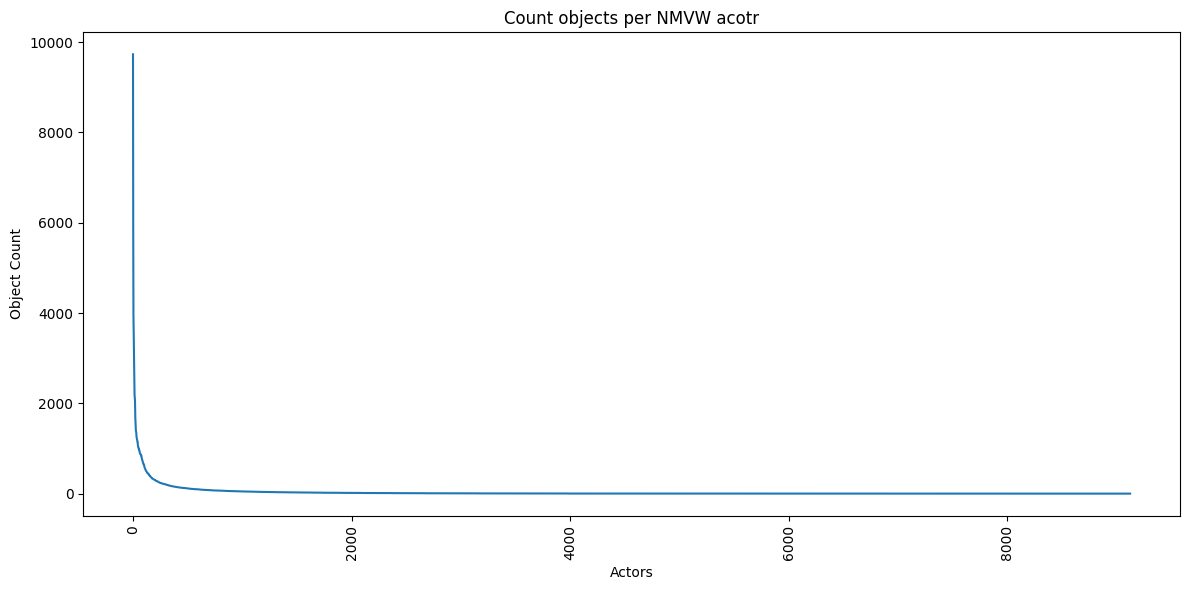

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import math

# Calculate the number of samples to extract
num_samples = math.ceil(len(df_nmvw_obj)/1)

# Calculate the interval size
interval_size = len(df_nmvw_obj) // num_samples

# Extract samples
samples = df_nmvw_obj.iloc[::interval_size]

# Assuming df_nmvw_obj is your DataFrame with columns 'nmvw_actor' and 'count'

# Sort the DataFrame by count in descending order
samples_sorted = samples.sort_values(by='no_object', ascending=False)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=samples_sorted, x=samples_sorted.index, y='no_object')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Actors')
plt.ylabel('Object Count')
plt.title('Count objects per NMVW acotr')

# Show plot
plt.tight_layout()
plt.show()

## Attribute

### Generate [attribute_per_actor_nmvw.csv](attribute_per_actor_nmvw.csv)

PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(?p) AS ?n) ?actor
WHERE{
  GRAPH <https://pressingmatter.nl/NMVW/ccrdfconst.ttl>{
    ?actor ?p ?o.
    ?actor a crm:E21_Person .
    FILTER (?p != rdfs:type)
  }
}GROUP BY ?actor

In [6]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd
import math

df_nmvw_attr = pd.read_csv("attribute_per_actor_nmvw.csv")
# df_nmvw_attr = df_nmvw_attr.iloc[: , :-1]
df_nmvw_attr.columns = ['no_attribute', 'nmvw_actor']
df_nmvw_attr = df_nmvw_attr.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df_nmvw_attr['no_attribute'] = df_nmvw_attr['no_attribute'].apply(cleanup)


# take out unknown or onbekend
df_nmvw_attr = df_nmvw_attr[df_nmvw_attr['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi4332"]

# take out found unnumbered
df_nmvw_attr = df_nmvw_attr[df_nmvw_attr['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi58423"]

df_nmvw_attr = df_nmvw_attr.sort_values(['no_attribute'], ascending=False).reset_index()
df_nmvw_attr = df_nmvw_attr.drop('index', axis=1)
df_nmvw_attr.to_csv("attribute_per_actor_nmvw.csv", index=False)

In [7]:
# Count the number of unique nmvw_actor per no_attribute value
counts = df_nmvw_attr.groupby('no_attribute')['nmvw_actor'].nunique()

for no_attribute, count in counts.items():
    print(f"Number of unique 'nmvw_actor' for {no_attribute} attribute: {count}")

Number of unique 'nmvw_actor' for 1 attribute: 24654
Number of unique 'nmvw_actor' for 2 attribute: 7469
Number of unique 'nmvw_actor' for 3 attribute: 2157
Number of unique 'nmvw_actor' for 4 attribute: 1200
Number of unique 'nmvw_actor' for 5 attribute: 1409
Number of unique 'nmvw_actor' for 6 attribute: 1250
Number of unique 'nmvw_actor' for 7 attribute: 961
Number of unique 'nmvw_actor' for 8 attribute: 406
Number of unique 'nmvw_actor' for 9 attribute: 110
Number of unique 'nmvw_actor' for 10 attribute: 1


In [8]:
print(df_nmvw_attr['no_attribute'].describe())

count    39617.000000
mean         1.928036
std          1.652501
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: no_attribute, dtype: float64


#### Plot the attribute distribution per actor

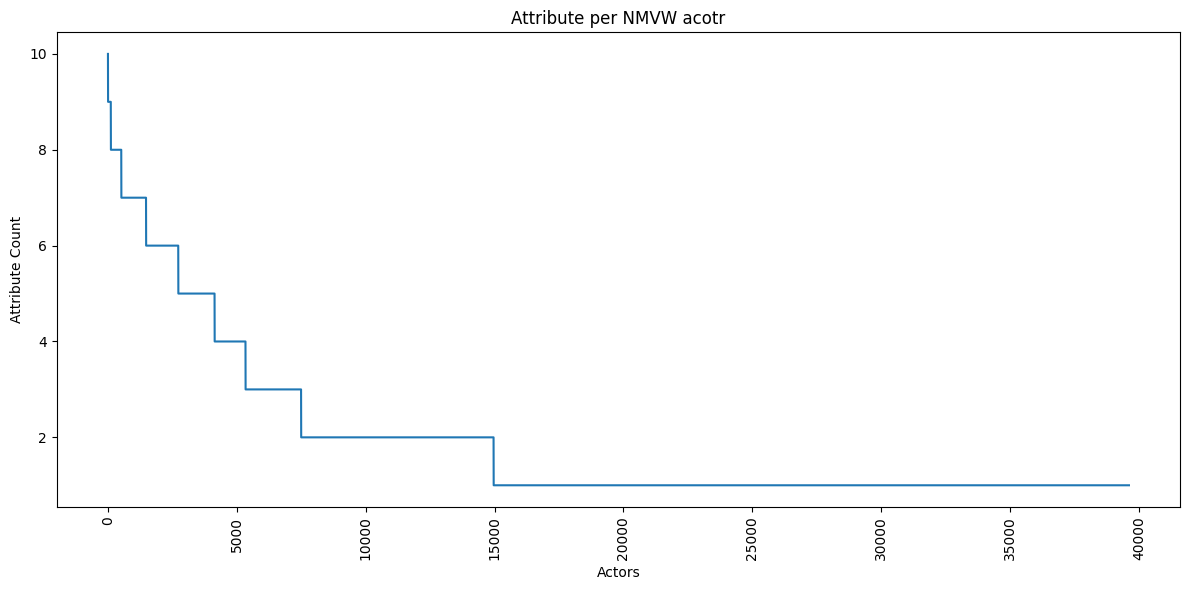

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import math

# Calculate the number of samples to extract
num_samples = math.ceil(len(df_nmvw_attr)/1)

# Calculate the interval size
interval_size = len(df_nmvw_attr) // num_samples

# Extract samples
samples = df_nmvw_attr.iloc[::interval_size]

# Assuming df_nmvw_attr is your DataFrame with columns 'nmvw_actor' and 'count'

# Sort the DataFrame by count in descending order
samples_sorted = samples.sort_values(by='no_attribute', ascending=False)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=samples_sorted, x=samples_sorted.index, y='no_attribute')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Actors')
plt.ylabel('Attribute Count')
plt.title('Attribute per NMVW acotr')

# Show plot
plt.tight_layout()
plt.show()

In [10]:
# Merge the DataFrames on 'nmvw_actor'
merged_df = pd.merge(df_nmvw_obj, df_nmvw_attr, on='nmvw_actor')

In [11]:
merged_df

,no_object,nmvw_actor,no_attribute
0,9729,https://hdl.handle.net/20.500.11840/pi2246,6
1,5996,https://hdl.handle.net/20.500.11840/pi1054,6
2,5845,https://hdl.handle.net/20.500.11840/pi5989,6
3,4004,https://hdl.handle.net/20.500.11840/pi58965,6
4,3972,https://hdl.handle.net/20.500.11840/pi3254,9
...,...,...,...
9119,1,https://hdl.handle.net/20.500.11840/pi63801,2
9120,1,https://hdl.handle.net/20.500.11840/pi81430,4
9121,1,https://hdl.handle.net/20.500.11840/pi81431,4
9122,1,https://hdl.handle.net/20.500.11840/pi63840,3


In [17]:
merged_df['no_attribute'].corr(merged_df['no_object'])

0.17845196106961275

<Axes: xlabel='no_attribute', ylabel='no_object'>

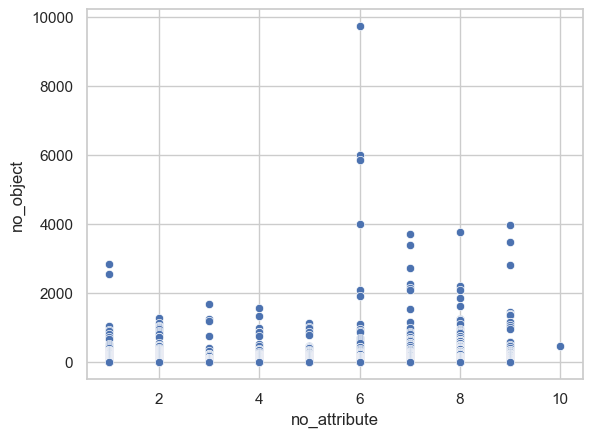

In [18]:
import seaborn
 
 
seaborn.set(style='whitegrid')
seaborn.scatterplot(x='no_attribute', y='no_object', data=merged_df)

## Bronbeek

### Generate [object_per_actor_bb.csv](object_per_actor_bb.csv)
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(DISTINCT ?bb_obj) AS ?no_object) ?bb_actor
WHERE{
    {?bb_acq crm:P23_transferred_title_from ?bb_actor .	
    ?bb_acq crm:P24_transferred_title_of ?bb_obj .}
    UNION
    {
          ?bb_obj crm:P51_has_former_or_current_owner ?bb_actor .
    }

GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
}GROUP BY ?bb_actor
```

In [19]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd

df_bb = pd.read_csv("object_per_actor_bb.csv")
# df_bb = df_bb.iloc[: , :-1]
df_bb.columns = ['no_object', 'bb_actor']
df_bb['no_object'] = df_bb['no_object'].apply(cleanup)

df_bb = df_bb.sort_values(by=['no_object'], ascending=False).reset_index()
df_bb = df_bb.drop('index', axis=1)
df_bb.to_csv("object_per_actor_bb.csv", index=False)

In [20]:
# Define the ranges
ranges = {
    '1': (0, 1),
    '2-10': (2, 10),
    '10-100': (10, 100),
    '100-1000': (100, 1000),
    'more than 1000': (1000, float('inf'))
}

# Function to count rows within a specified range
def count_rows_in_range(df, col, range_tuple):
    return df[(df[col] > range_tuple[0]) & (df[col] <= range_tuple[1])].shape[0]

# Calculate the counts for each range
counts = {range_name: count_rows_in_range(df_bb, 'no_object', range_tuple) for range_name, range_tuple in ranges.items()}

# Print the results
for range_name, count in counts.items():
    print(f"Number of rows with 'no_object' values in range {range_name}: {count}")


Number of rows with 'no_object' values in range 1: 2589
Number of rows with 'no_object' values in range 2-10: 2090
Number of rows with 'no_object' values in range 10-100: 1176
Number of rows with 'no_object' values in range 100-1000: 220
Number of rows with 'no_object' values in range more than 1000: 8


### Description
- Note: https://pressingmatter.nl/Bronbeek/Constituents/1896" --> "Koninklijk Tehuis voor Oud-Militairen en Museum Bronbeek"^^xsd:string
- https://pressingmatter.nl/Bronbeek/Constituents/9806 --> Nijmeegs Volkenkundig Museum
- https://pressingmatter.nl/Bronbeek/Constituents/9804 --> "Gemeente Nijmegen"
- https://pressingmatter.nl/Bronbeek/Constituents/9805 --> Jean Louis Henri Beijens

In [21]:
df_bb['no_object'].describe()

count     7118.000000
mean        17.745013
std        169.097980
min          1.000000
25%          1.000000
50%          2.000000
75%          8.000000
max      12409.000000
Name: no_object, dtype: float64

In [22]:
# Removing all the acotrs above 1000
df_bb = df_bb[8:]

In [23]:
df_bb['no_object'].describe()

count    7110.000000
mean       13.967089
std        45.591723
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
max       800.000000
Name: no_object, dtype: float64

### Plot the object distribution per actor

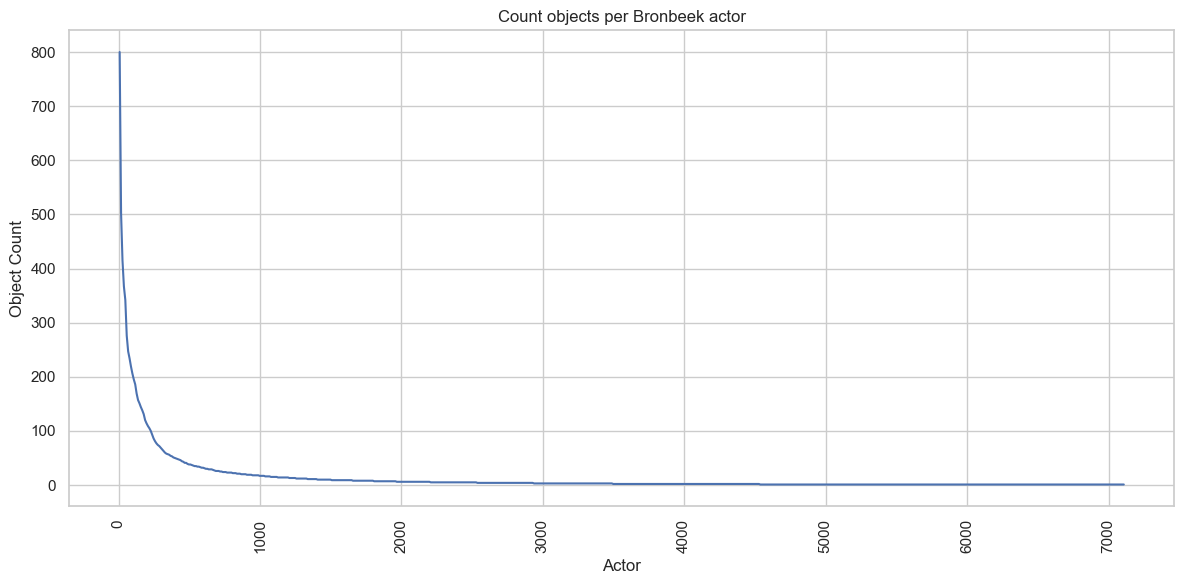

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import math

# Calculate the number of samples to extract
num_samples = math.ceil(len(df_bb)/10.0)

# Calculate the interval size
interval_size = len(df_bb) // num_samples

# Extract samples
samples = df_bb.iloc[::interval_size]

# Sort the DataFrame by count in descending order
samples_sorted = samples.sort_values(by='no_object', ascending=False)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=samples_sorted, x=samples_sorted.index, y='no_object')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Actor')
plt.ylabel('Object Count')
plt.title('Count objects per Bronbeek actor')

# Show plot
plt.tight_layout()
plt.show()

# CQ-1a

How many actor we have from NMVW side?

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT (COUNT(DISTINCT ?nmvw_actor) AS ?no_nmvw_actor) 
WHERE{
  GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
  {?nmvw_acq crm:P24_transferred_title_of ?nmvw_object .
   ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .}
  UNION
  {
    ?nmvw_prod crm:P14_carried_out_by ?nmvw_actor .
    ?nmvw_object crm:P108i_was_produced_by ?nmvw_prod .
  }
  ?nmvw_object a crm:E22_Human-Made_Object .
  }
}
```
> There is 11,955 actors from nmvw who has connection with object provenance

How many actors we have with one more objects from Bronbeek side?

SPARQL Query:
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT (COUNT(DISTINCT ?bb_actor) AS ?no_bb_actor) 
WHERE{
    #acquisition event
    {
    	?bb_acq crm:P23_transferred_title_from ?bb_actor .   
    	?bb_acq crm:P24_transferred_title_of ?bb_object .
    }
  UNION
    {
      	?bb_object crm:P51_has_former_or_current_owner ?bb_actor .
    }
  GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_object a crm:E22_Human-Made_Object .
    }
}
```
> There is 7118 actors from Bronbeek who has connection with object provenance

So, if nmvw and Bronbeek had 1-1 correspondance there could maximun 7118 correspondance. 

Generate [CQ1a_x.csv](CQ1a_x.csv):

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT DISTINCT ?nmvw_actor
WHERE{
  GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
  {?nmvw_acq crm:P24_transferred_title_of ?nmvw_object .
   ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .}
  UNION
  {
    ?nmvw_prod crm:P14_carried_out_by ?nmvw_actor .
    ?nmvw_object crm:P108i_was_produced_by ?nmvw_prod .
  }
  ?nmvw_object a crm:E22_Human-Made_Object .
  }
  ?nmvw_actor owl:sameAs ?bb_actor .
}
```

In [ ]:
import pandas as pd

df_delta_deezy = pd.read_csv("CQ1a_deezy.csv")
df_delta_deezy.columns = ['nmvw_actor']
df_delta_deezy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_deezy['nmvw_actor'])]

df_delta_exact = pd.read_csv("CQ1a_exact.csv")
df_delta_exact.columns = ['nmvw_actor']
df_delta_exact = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_exact['nmvw_actor'])]

df_delta_initial = pd.read_csv("CQ1a_initial.csv")
df_delta_initial.columns = ['nmvw_actor']
df_delta_initial = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_initial['nmvw_actor'])]

df_delta_surname = pd.read_csv("CQ1a_surname.csv")
df_delta_surname.columns = ['nmvw_actor']
df_delta_surname = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_surname['nmvw_actor'])]

df_delta_fuzzy = pd.read_csv("CQ1a_fuzzy.csv")
df_delta_fuzzy.columns = ['nmvw_actor']
df_delta_fuzzy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_fuzzy['nmvw_actor'])]

In [ ]:
df_delta_fuzzy['no_object'].describe()

#### Plot distribution

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import math

# Calculate the number of samples to extract
num_samples = math.ceil(len(df_nmvw)/10.0)

# Calculate the interval size
interval_size = len(df_nmvw) // num_samples

# Extract samples
samples = df_nmvw.iloc[::interval_size]

# Assuming df_nmvw is your DataFrame with columns 'nmvw_actor' and 'count'

# Sort the DataFrame by count in descending order
samples_sorted = samples.sort_values(by='no_object', ascending=False)


# plt.figure(figsize=(12, 6))
fig, ax1 = plt.subplots(figsize=(12,6))
# Create line plot
sns.lineplot(data=samples_sorted, x=samples_sorted.index, y='no_object', ax=ax1)
ax2 = ax1.twinx()
# Create bar plot
sns.barplot(data = df_delta, x=df_delta.index, y='no_object', alpha=0.5, ax=ax2)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Actor')
plt.ylabel('Object Count')
plt.title('Count objects per NMVW acotr')

# Show plot
plt.tight_layout()
plt.show()

#### Box plot

In [ ]:
# converting object number to log
df_nmvw['no_object'] = df_nmvw['no_object'].apply(lambda x: math.log(x))
df_delta_deezy['no_object'] = df_delta_deezy['no_object'].apply(lambda x: math.log(x))
df_delta_exact['no_object'] = df_delta_exact['no_object'].apply(lambda x: math.log(x))
df_delta_initial['no_object'] = df_delta_initial['no_object'].apply(lambda x: math.log(x))
df_delta_surname['no_object'] = df_delta_surname['no_object'].apply(lambda x: math.log(x))
df_delta_fuzzy['no_object'] = df_delta_fuzzy['no_object'].apply(lambda x: math.log(x))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Sample data (replace with your actual data)
data = {
    'NMVW Actors': df_nmvw['no_object'],
    'Deezy Match': df_delta_deezy['no_object'] ,
    'Exact Match': df_delta_exact['no_object'],
    'Initial+Surname Match': df_delta_initial['no_object'],
    'Surname Match': df_delta_surname['no_object'],
    'Fuzzy Match': df_delta_fuzzy['no_object'] 
}

# Combine data into a single DataFrame
df = pd.DataFrame({key: pd.Series(value) for key, value in data.items()})

# Melt the DataFrame to have a single column for series identifiers
df_melted = df.melt(var_name='Series')

# Create box plot using Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='variable', y='value', data=pd.melt(df), widths=0.1)
plt.title('Box Plot of Multiple Series')
plt.xlabel('Actors')
plt.ylabel('Logarithm of Object  Count')
plt.show()

#### Count Quartile

In [ ]:
quartiles = df1['no_object'].quantile([0.25, 0.5, 0.75])

# Function to determine quartile
def get_quartile(value):
    if value <= quartiles[0.25]:
        return 'Q1'
    elif value <= quartiles[0.5]:
        return 'Q2'
    elif value <= quartiles[0.75]:
        return 'Q3'
    else:
        return 'Q4'

# Apply the function to column2 from df2 to get quartile information
df_delta['quartile'] = df_delta['no_object'].apply(get_quartile)

df_delta['quartile'].value_counts()

# CQ 1b

Query to generate [CQ1b_nmvw_obj.csv](CQ1b_nmvw_obj.csv)
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT ?nmvw_object ?nmvw_actor
WHERE{
  GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
  {?nmvw_acq crm:P24_transferred_title_of ?nmvw_object .
   ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .}
  UNION
  {
    ?nmvw_prod crm:P14_carried_out_by ?nmvw_actor .
    ?nmvw_object crm:P108i_was_produced_by ?nmvw_prod .
  }
  ?nmvw_object a crm:E22_Human-Made_Object .
  }
  # removing "onbeked / unknown"
  FILTER (?nmvw_actor != <https://hdl.handle.net/20.500.11840/pi4332>)
}
```

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd

df1 = pd.read_csv("CQ1b_nmvw_obj.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]
df1.columns = ['nmvw_object', 'nmvw_actor']

Generate [CQ1b_bb_obj.csv](CQ1b_bb_obj.csv)

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT (COUNT(DISTINCT ?bb_object) AS ?n_bb_object) 
WHERE{
    #acquisition event
    {
    	?bb_acq crm:P23_transferred_title_from ?bb_actor .   
    	?bb_acq crm:P24_transferred_title_of ?bb_object .
    }
  UNION
    {
      	?bb_object crm:P51_has_former_or_current_owner ?bb_actor .
    }
  GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_object a crm:E22_Human-Made_Object .
    }
}
```
> number of unique object from 7,118 actor is: 85,632. So, on verage everyone should have 12 objects. 

Generate [CQ1b_delta.csv](CQ1b_delta.csv):
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT ?nmvw_actor (COUNT(DISTINCT ?bb_object) AS ?n_bb_object) 
WHERE{
    ?nmvw_actor owl:sameAs ?bb_actor .
    #acquisition event
    {
    	?bb_acq crm:P23_transferred_title_from ?bb_actor .   
    	?bb_acq crm:P24_transferred_title_of ?bb_object .
    }
  UNION
    {
      	?bb_object crm:P51_has_former_or_current_owner ?bb_actor .
    }
  GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_object a crm:E22_Human-Made_Object .
    }
} GROUP BY ?nmvw_actor
```

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd

df2 = pd.read_csv("CQ1b_delta.csv")
df2 = df2.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
# df2 = df2.iloc[: , :-1]
df2.columns = ["nmvw_actor", "bb_object" ]
df2['bb_object'] = df2['bb_object'].apply(cleanup)

df2 = df2[df2['nmvw_actor'].isin(df1['nmvw_actor'])]

In [ ]:
filtered_df1 = df1[df1['nmvw_actor'].isin(df2['nmvw_actor'])]
exact = filtered_df1.groupby(['nmvw_actor'])['nmvw_object'].nunique()

In [ ]:
exact.sort_values(ascending=False).describe()

In [ ]:
import pandas as pd
import numpy as np

# Define two sample series of different lengths
series1 = all_actors
series2 = exact

# Determine the length of the longest series
max_length = max(len(series1), len(series2))

# Pad the shorter series with NaN values to match the length of the longest series
if len(series1) < max_length:
    series1 = series1.reindex(range(max_length))
if len(series2) < max_length:
    series2 = series2.reindex(range(max_length))

# Create a DataFrame with the two series as columns
df = pd.DataFrame({'NMVW Actors': series1, 'Exact Match': series2})

print(df)

In [ ]:
df.reset_index

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data (replace with your actual data)
data = {
    'NMVW Actors': all_actors,
    'Exact Match': exact
}

# Combine data into a single DataFrame
df = pd.DataFrame({key: pd.Series(value) for key, value in data.items()})

# Melt the DataFrame to have a single column for series identifiers
df_melted = df.melt(var_name='Series')


df_melted

In [ ]:
# Create box plot using Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='variable', y='value', data=pd.melt(df))
plt.title('Box Plot of Multiple Series')
plt.xlabel('Series')
plt.ylabel('Values')
plt.show()


# CQ 2

SPARQL Query:
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT (COUNT(DISTINCT ?nmvw_object) AS ?n)
WHERE{
  Graph <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
    {
     ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .
     ?nmvw_acq crm:P24_transferred_title_of ?nmvw_object .
    }
    UNION
    {
      ?nmvw_object crm:P108i_was_produced_by ?nmvw_prod .
      ?nmvw_prod crm:P14_carried_out_by ?nmvw_actor .
    }
    ?nmvw_object  a crm:E22_Human-Made_Object .
  }
}
```
> The number of total object from NMVW with actor is: 484,761
> The number of total actor is: 11955
> The number of average object per actor: 40.5

# CQ 3

Generate [CQ3_nmvw_obj.csv](CQ3_nmvw_obj.csv)
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT *
WHERE{
  Graph <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
     ?nmvw_acq1 crm:P23_transferred_title_from ?nmvw_actor1 .
     ?nmvw_acq1 crm:P24_transferred_title_of ?nmvw_object .
    
    ?nmvw_acq2 crm:P24_transferred_title_of ?nmvw_object .
    ?nmvw_acq2 crm:P23_transferred_title_from ?nmvw_actor2 .
    
    Filter (?nmvw_actor1!= ?nmvw_actor2)
   }
}
```

In [ ]:
import pandas as pd

df1 = pd.read_csv("CQ3_nmvw_obj.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]
df1.columns = ["nmvw_acq1" , "nmvw_actor1" , "nmvw_object" , "nmvw_acq2" , "nmvw_actor2"]

pairs = set(frozenset(pair) for pair in zip(df1['nmvw_actor1'], df1['nmvw_actor2']))
df1 = pd.DataFrame(pairs, columns=['nmvw_actor1', 'nmvw_actor2'])

print(f"Unique two person's pair in nmvw dataset is: {len(df1)}")

generate [CQ3_bb_obj.csv](CQ3_bb_obj.csv)

```
SELECT * WHERE{
     ?bb_acq1 crm:P23_transferred_title_from ?bb_actor1 .
     ?bb_acq1 crm:P24_transferred_title_of ?bb_object .
    
    ?bb_acq2 crm:P24_transferred_title_of ?bb_object .
    ?bb_acq2 crm:P23_transferred_title_from ?bb_actor2 .

    Filter (?bb_actor1!= ?bb_actor2)
Graph <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
        ?bb_object a crm:E22_Human-Made_Object.
   }
}
```

In [ ]:
import pandas as pd

df2 = pd.read_csv("CQ3_bb_obj.csv")
# df2 = df2.iloc[: , :-1]
df2.columns = [  "bb_acq1" , "bb_actor1" , "bb_object" , "bb_acq2" , "bb_actor2"]

pairs = set(frozenset(pair) for pair in zip(df2['bb_actor1'], df2['bb_actor2']))
df2 = pd.DataFrame(pairs, columns=['bb_actor1', 'bb_actor2'])

print(f"Unique two person's pair in bronbeek dataset is: {len(df2)}")


Download the match results in [sameAs.csv](sameAs.csv)

SPARQL QUERY:
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT * WHERE{
  ?nmwv_actor owl:sameAs ?bb_actor .
}
```

In [ ]:
match_df = pd.read_csv("sameAs.csv")
# match_df = match_df.iloc[:, :-1]
match_df.columns = [ "nmvw_actor" , "bb_actor"]

merged_df1 = df1.merge(match_df, left_on='nmvw_actor1', right_on='nmvw_actor', how='inner')
merged_df2 = df1.merge(match_df, left_on='nmvw_actor2', right_on='nmvw_actor', how='inner')
final_df = pd.concat([merged_df1, merged_df2])
final_df = final_df.drop_duplicates()

result_df1 = final_df.merge(df2, left_on='bb_actor', right_on='bb_actor1', how='inner')
result_df2 = final_df.merge(df2, left_on='bb_actor', right_on='bb_actor2', how='inner')
result_df = pd.concat([result_df2,result_df1])

In [ ]:
pair_list = list()

for _, row in result_df.iterrows():
    if row['nmvw_actor1'] == row['nmvw_actor']:
        x1 = row['nmvw_actor1']
        x = row['nmvw_actor2']
    else:
        x = row['nmvw_actor1']

    if row['bb_actor1'] == row['bb_actor']:
        y =  row['bb_actor2']
    else:
        y =  row['bb_actor1']
    
    pair_list.append(frozenset((x,y)))
    try:
        pair_list.append(frozenset((x1,y)))
    except NameError:
        print(f"{row['nmvw_actor1']} never apprears in sameAs")

pair_set = set(pair_list)
pair_df = pd.DataFrame(pair_set, columns=['actor1', 'actor2'])

print(f"The number of new pairs of actor-to-actor connection added is: {len(pair_df)}")

# CQ 4

##### These are the objects, where we do not know it's production place, but do know the acqusuiton actor.
> For 49152 object we did not know the production location

```PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(DISTINCT ?nmvw_obj) AS ?no_object) ?nmvw_actor
WHERE{
 GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
    ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor.
    ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
    ?nmvw_obj crm:P108i_was_produced_by ?nmvw_prod .
    FILTER NOT EXISTS {
      ?nmvw_prod crm:P7_took_place_at ?nmvw_prod_place.}
    }
} GROUP BY ?nmvw_actor ```

##### These are the objects, where we DO KNOW it's production place, and acqusuiton actor.
> For 457722 object, we did not know the production location
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(DISTINCT ?nmvw_obj) AS ?no_object) (COUNT(DISTINCT ?nmvw_prod_place) AS ?no_place) ?nmvw_actor
WHERE{
 GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
     ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor.
      ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
      ?nmvw_obj crm:P108i_was_produced_by ?nmvw_prod .
     ?nmvw_prod crm:P7_took_place_at ?nmvw_prod_place.
    }
} GROUP BY ?nmvw_actor 
```

> If we connect them with acqusistion_actor, for 45756 objects we can prioritise possible location .

> 85632 object
> 7118 acotr
> object on average: 12

In [ ]:
import pandas as pd

df1 = pd.read_csv("CQ4_nmvw_object_place_unknown.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df2 = pd.read_csv("CQ4_nmvw_object_place_known.csv")
df2 = df2.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)

In [ ]:
merged_df_nmvw = pd.merge(df1, df2, on='nmvw_actor', how='inner')
print(f"From nmvw dataset, we have {merged_df_nmvw['no_object_x'].sum()} objects where they are connected to actor whose at least one object has known production location.")

##### Object connected to Bronbeek actors that as sameAs Links with NMVW

Query to generate [CQ4_bb_object.csv](CQ4_bb_object.csv):

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(DISTINCT ?bb_obj) AS ?no_object) ?bb_actor
WHERE{
    ?nmvw_actor owl:sameAs ?bb_actor .
    {?bb_acq crm:P23_transferred_title_from ?bb_actor .	
    ?bb_acq crm:P24_transferred_title_of ?bb_obj .}
    UNION{
          ?bb_obj crm:P51_has_former_or_current_owner ?bb_actor .
}

 GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
} GROUP BY ?bb_actor 
```

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

df3 = pd.read_csv("CQ4_bb_object.csv")
df3 = df3.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
# df3 = df3.iloc[: , :-1]
df3.columns = ["no_object" , "bb_actor"]
df3['no_object'] = df3['no_object'].apply(cleanup)
print(f"From bronbeek dataset, we have {df3['no_object'].sum()} objects that are connected with an actor who have owl:sameAs link to nmvw dataset")

Query Generate [sameAs.csv](sameAs.csv):
```
SELECT * WHERE{
    ?nmvw_actor owl:sameAs ?bb_actor .
}
```

In [ ]:
df4 = pd.read_csv("sameAs.csv")
df4 = df4.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
# df4 = df4.iloc[: , :-1]
df4.columns = ['nmvw_actor' , 'bb_actor']

In [ ]:
merged_df = pd.merge(df3, df4, on='bb_actor', how='inner')
# when there is multiple match on the bb actor, only kept the first match
merged_df = merged_df.drop_duplicates(subset='bb_actor')
merged_df = pd.merge(merged_df, df2, on='nmvw_actor', how='inner')
merged_df['no_object_x'].sum()

In [ ]:
merged_df.to_csv('CQ4_surname.csv', index=False)

- **Exact String match:** Now for 0 bronbeek object, we can potentially project possible location.
- **Initial+surname match:** Now for 1841 bronbeek objects, we can potentially project possible location.
- **Surname match:** Now for 12776 bronbeek objects, we can potentially project possible location.
- **Fuzzy String match:** Now for 16503 bronbeek objects, we can potentially project possible location.

### Plot distribution

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd
import math

df_nmvw = pd.read_csv("object_per_actor_nmvw.csv")
df_nmvw = df_nmvw.iloc[: , :-1]
df_nmvw.columns = ['no_object', 'nmvw_actor']
df_nmvw = df_nmvw.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df_nmvw['no_object'] = df_nmvw['no_object'].apply(cleanup)

# take out unkonw or onbekend
df_nmvw = df_nmvw[df_nmvw['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi4332"]

df_nmvw = df_nmvw.sort_values(['no_object'], ascending=False).reset_index()
df_nmvw = df_nmvw.drop('index', axis=1)

In [ ]:
df_CQ4_nmvw = df1[df1['nmvw_actor'].isin(merged_df_nmvw['nmvw_actor'])]

In [ ]:
import pandas as pd

df_delta_deezy = pd.read_csv("CQ4_deezy.csv")
# df_delta_deezy.columns = ['nmvw_actor']
df_delta_deezy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_deezy['nmvw_actor'])]

df_delta_exact = pd.read_csv("CQ4_exact.csv")
# df_delta_exact.columns = ['nmvw_actor']
df_delta_exact = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_exact['nmvw_actor'])]

df_delta_initial = pd.read_csv("CQ4_initial.csv")
# df_delta_initial.columns = ['nmvw_actor']
df_delta_initial = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_initial['nmvw_actor'])]

df_delta_surname = pd.read_csv("CQ4_surname.csv")
# df_delta_surname.columns = ['nmvw_actor']
df_delta_surname = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_surname['nmvw_actor'])]

df_delta_fuzzy = pd.read_csv("CQ4_fuzzy.csv")
# df_delta_fuzzy.columns = ['nmvw_actor']
df_delta_fuzzy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_fuzzy['nmvw_actor'])]

In [ ]:
df_CQ4_nmvw['no_object'].describe()

In [ ]:
# converting object number to log
df_nmvw['no_object'] = df_nmvw['no_object'].apply(lambda x: math.log(x))
df_CQ4_nmvw['no_object'] = df_CQ4_nmvw['no_object'].apply(lambda x: math.log(x))
df_delta_deezy['no_object'] = df_delta_deezy['no_object'].apply(lambda x: math.log(x))
df_delta_exact['no_object'] = df_delta_exact['no_object'].apply(lambda x: math.log(x))
df_delta_initial['no_object'] = df_delta_initial['no_object'].apply(lambda x: math.log(x))
df_delta_surname['no_object'] = df_delta_surname['no_object'].apply(lambda x: math.log(x))
df_delta_fuzzy['no_object'] = df_delta_fuzzy['no_object'].apply(lambda x: math.log(x))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Sample data (replace with your actual data)
data = {
    'NMVW Actors': df_nmvw['no_object'],
    'Actor-related to Place': df_CQ4_nmvw['no_object'],
    'Deezy Match': df_delta_deezy['no_object'] ,
    'Exact Match': df_delta_exact['no_object'],
    'Initial+Surname Match': df_delta_initial['no_object'],
    'Surname Match': df_delta_surname['no_object'],
    'Fuzzy Match': df_delta_fuzzy['no_object'] 
}

# Combine data into a single DataFrame
df = pd.DataFrame({key: pd.Series(value) for key, value in data.items()})

# Melt the DataFrame to have a single column for series identifiers
df_melted = df.melt(var_name='Series')

# Create box plot using Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='variable', y='value', data=pd.melt(df), widths=0.1)
plt.title('Box Plot of Multiple Series')
plt.xlabel('Actors')
plt.ylabel('Logarithm of Object  Count')
plt.show()

# CQ-5

```
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>

SELECT (AVG(?n) AS ?avg) WHERE
{
  SELECT (COUNT(DISTINCT ?nmvw_obj) AS ?n) 
  WHERE{
      GRAPH <https://pressingmatter.nl/NMVW/ccrdfhiseve.ttl>{
      ?histevet a crm:E7_Activity .
      ?histevet crm:P140i_was_attributed_by ?o .
      ?histevet  crm:P1_is_identified_by ?title .
      ?histevet crm:P4_has_time-span [crm:P82a_begin_of_the_begin ?histevet_btime;
                                       crm:P82b_end_of_the_end ?histevet_etime] .
      ?title crm:P190_has_symbolic_content ?histevet_name .
      ?o a crm:E13_Attribute_Assignment .
      ?o crm:P141_assigned ?nmvw_obj .
    } 
    ?nmvw_obj a crm:E22_Human-Made_Object .
}GROUP BY ?histevet
}
```
> Average object per event: 261.941 with 51 event

Query to download ([CQ5_nmvw.csv](CQ5_nmvw.csv))

```
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX owl: <http://www.w3.org/2002/07/owl#>

SELECT ?histevet ?histevet_btime ?histevet_etime ?nmvw_obj ?nmvw_actor 
  WHERE{
      GRAPH <https://pressingmatter.nl/NMVW/ccrdfhiseve.ttl>{
      ?histevet a crm:E7_Activity .
      ?histevet crm:P140i_was_attributed_by ?o .
      ?histevet  crm:P1_is_identified_by ?title .
      ?histevet crm:P4_has_time-span [crm:P82a_begin_of_the_begin ?histevet_btime;
                                       crm:P82b_end_of_the_end ?histevet_etime] .
      ?title crm:P190_has_symbolic_content ?histevet_name .
      ?o a crm:E13_Attribute_Assignment .
      ?o crm:P141_assigned ?nmvw_obj .
    } 
    ?nmvw_obj a crm:E22_Human-Made_Object .
    ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
    ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor .	
  	?nmvw_actor owl:sameAs ?bb_actor .
}
```

In [ ]:
import pandas as pd

def cleanup_time(x: str):
    # print(type(x))
    return int(str(x).replace('"', '').strip()[:4])

df1 = pd.read_csv("CQ5_nmvw.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]
df1.columns = [ "histevet" , "histevet_btime" , "histevet_etime" , "nmvw_obj" , "nmvw_actor"]
df1['histevet_btime'] = df1['histevet_btime'].apply(cleanup_time)
df1['histevet_etime'] = df1['histevet_etime'].apply(cleanup_time)

# drop the nmvw_obj
df1 = df1.drop(['nmvw_obj'], axis=1)
# Remove duplicate actor to event connections
df1 = df1.drop_duplicates()
df1

Query to generate [CQ5_bb.csv](CQ5_bb.csv)

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?bb_obj ?bb_actor ?nmvw_actor ?b_time ?e_time
WHERE{
  	?nmvw_actor owl:sameAs ?bb_actor .
  	?bb_acq2 crm:P23_transferred_title_from ?bb_actor . 
  	?bb_acq2 crm:P24_transferred_title_of ?bb_obj .
    ?prov_activity  crm:P9_consists_of ?bb_acq2 .
    ?prov_activity crm:P2_has_type aat:300055863 .
  	
    ?prov_activity crm:P9_consists_of ?bb_acq .
  	?bb_acq crm:P24_transferred_title_of ?bb_obj .
	  ?bb_acq crm:P4_has_time-span ?time .
  	?time crm:P82a_begin_of_the_begin ?b_time .
    ?time crm:P82b_end_of_the_end ?e_time.
  FILTER (?bb_acq != ?bb_acq2) .

GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
}
```

In [ ]:
def cleanup_time(x: str):
    # Check if x is not None and not an empty string
    try:
        if x == "None" :
            return 0
        if x and str(x).strip():
            # Convert the cleaned string to an integer
            return int(str(x).replace('"', '').strip()[:4])
    except ValueError:
        return 0

# Read the second CSV file into DataFrame df2
df2 = pd.read_csv("CQ5_bb.csv")
df2 = df2.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)

# df2 = df2.iloc[: , :-1]
df2.columns = ["bb_obj" , "bb_actor" , "nmvw_actor" , "b_time" , "e_time"]
df2['b_time'] = df2['b_time'].apply(cleanup_time)
df2['e_time'] = df2['e_time'].apply(cleanup_time)

# Remove duplicate rows in df2
df2 = df2.drop_duplicates() 

# remove bb_actor matched to multiple nmvw_actor
# df2 = df2.drop_duplicates(subset=['bb_obj'])

# Extract unique 'nmvw_actor' values from df2
unique_nmvw_actor = df1['nmvw_actor'].unique()

# Filter df2 to keep only rows where 'nmvw_actor' exists in df2
df2= df2[df2['nmvw_actor'].isin(unique_nmvw_actor)]

df2 = df2.sort_values('bb_actor')

### Plot distribution

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd
import math

df_nmvw = pd.read_csv("object_per_actor_nmvw.csv")
df_nmvw = df_nmvw.iloc[: , :-1]
df_nmvw.columns = ['no_object', 'nmvw_actor']
df_nmvw = df_nmvw.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df_nmvw['no_object'] = df_nmvw['no_object'].apply(cleanup)

# take out unkonw or onbekend
df_nmvw = df_nmvw[df_nmvw['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi4332"]

df_nmvw = df_nmvw.sort_values(['no_object'], ascending=False).reset_index()
df_nmvw = df_nmvw.drop('index', axis=1)

In [ ]:
df_CQ5_nmvw = df_nmvw[df_nmvw['nmvw_actor'].isin(df1['nmvw_actor'])]

In [ ]:
import pandas as pd

df_delta_deezy = pd.read_csv("CQ5_deezy.csv")
# df_delta_deezy.columns = ['nmvw_actor']
df_delta_deezy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_deezy['nmvw_actor'])]

df_delta_exact = pd.read_csv("CQ5_exact.csv")
# df_delta_exact.columns = ['nmvw_actor']
df_delta_exact = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_exact['nmvw_actor'])]

df_delta_initial = pd.read_csv("CQ5_initial.csv")
# df_delta_initial.columns = ['nmvw_actor']
df_delta_initial = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_initial['nmvw_actor'])]

df_delta_surname = pd.read_csv("CQ5_surname.csv")
# df_delta_surname.columns = ['nmvw_actor']
df_delta_surname = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_surname['nmvw_actor'])]

df_delta_fuzzy = pd.read_csv("CQ5_fuzzy.csv")
# df_delta_fuzzy.columns = ['nmvw_actor']
df_delta_fuzzy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_fuzzy['nmvw_actor'])]

In [ ]:
df_delta_fuzzy['no_object'].describe()

In [ ]:
# converting object number to log
df_nmvw['no_object'] = df_nmvw['no_object'].apply(lambda x: math.log(x))
df_CQ5_nmvw['no_object'] = df_CQ5_nmvw['no_object'].apply(lambda x: math.log(x))
df_delta_deezy['no_object'] = df_delta_deezy['no_object'].apply(lambda x: math.log(x))
df_delta_exact['no_object'] = df_delta_exact['no_object'].apply(lambda x: math.log(x))
df_delta_initial['no_object'] = df_delta_initial['no_object'].apply(lambda x: math.log(x))
df_delta_surname['no_object'] = df_delta_surname['no_object'].apply(lambda x: math.log(x))
df_delta_fuzzy['no_object'] = df_delta_fuzzy['no_object'].apply(lambda x: math.log(x))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Sample data (replace with your actual data)
data = {
    'NMVW Actors': df_nmvw['no_object'],
    'Actor-related to Historical Event': df_CQ5_nmvw['no_object'],
    'Deezy Match': df_delta_deezy['no_object'] ,
    'Exact Match': df_delta_exact['no_object'],
    'Initial+Surname Match': df_delta_initial['no_object'],
    'Surname Match': df_delta_surname['no_object'],
    'Fuzzy Match': df_delta_fuzzy['no_object'] 
}

# Combine data into a single DataFrame
df = pd.DataFrame({key: pd.Series(value) for key, value in data.items()})

# Melt the DataFrame to have a single column for series identifiers
df_melted = df.melt(var_name='Series')

# Create box plot using Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='variable', y='value', data=pd.melt(df), widths=0.1)
plt.setp(ax.get_xticklabels(), rotation=45)
plt.title('Box Plot of Multiple Series')
plt.xlabel('Actors')
plt.ylabel('Logarithm of Object  Count')
plt.show()

# CQ-6a

Query to generate [CQ6a_nmvw.csv](CQ6a_nmvw.csv): 

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?nmvw_obj ?nmvw_actor ?b_time ?e_time
WHERE{
 GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
     ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor.
     ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
     ?prov_activity ?p ?nmvw_acq.
     ?prov_activity crm:P2_has_type aat:300055863 .
     ?prov_activity crm:P4_has_time-span ?time .
     ?time crm:P82a_begin_of_the_begin ?b_time .
     ?time crm:P82b_end_of_the_end ?e_time.
    }
}
```

In [ ]:
def cleanup_time(x: str):
    return int(str(x).replace('"', '').strip()[-4:])

import pandas as pd

df1 = pd.read_csv("CQ6a_nmvw.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]

df1.columns = ['nmvw_obj', 'nmvw_actor', 'b_time', 'e_time']
df1['b_time'] = df1['b_time'].apply(cleanup_time)
df1['e_time'] = df1['e_time'].apply(cleanup_time)
df1

In [ ]:
grouped_df = df1.groupby(['nmvw_actor', 'b_time', 'e_time'])['nmvw_obj'].nunique().reset_index()
grouped_df = grouped_df.sort_values(by='nmvw_obj', ascending=False)
grouped_df = grouped_df[grouped_df['nmvw_obj'] != 1]
print(f"Number of objects that can be connected with at least one other object \nbased on they are connected by same actor during similar time is: {grouped_df['nmvw_obj'].sum()}")

Query to generate: [CQ6a_bb.csv](CQ6a_bb.csv)

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?bb_obj ?bb_actor ?nmvw_actor ?b_time ?e_time
WHERE{
  	?nmvw_actor owl:sameAs ?bb_actor .
  	?bb_acq2 crm:P23_transferred_title_from ?bb_actor . 
  	?bb_acq2 crm:P24_transferred_title_of ?bb_obj .
    ?prov_activity  crm:P9_consists_of ?bb_acq2 .
    ?prov_activity crm:P2_has_type aat:300055863 .
  	
    ?prov_activity crm:P9_consists_of ?bb_acq .
  	?bb_acq crm:P24_transferred_title_of ?bb_obj .
	  ?bb_acq crm:P4_has_time-span ?time .
  	?time crm:P82a_begin_of_the_begin ?b_time .
    ?time crm:P82b_end_of_the_end ?e_time.
  FILTER (?bb_acq != ?bb_acq2) .

GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
}
```

In [ ]:
def cleanup_time(x: str):
    # Check if x is not None and not an empty string
    try:
        if x == "None" :
            return 0
        if x and str(x).strip():
            # Convert the cleaned string to an integer
            return int(str(x).replace('"', '').strip()[:4])
    except ValueError:
        return 0

import pandas as pd

df2 = pd.read_csv("CQ6a_bb.csv")
# df2 = df2.iloc[: , :-1]
df2.columns = ['bb_obj', 'bb_actor', 'nmvw_actor', 'b_time', 'e_time']
df2['b_time'] = df2['b_time'].apply(cleanup_time)
df2['e_time'] = df2['e_time'].apply(cleanup_time)

In [ ]:
def merge_with_condition(df1, df2):
    merged_df = pd.merge(df1, df2, on='nmvw_actor', how='inner')
    merged_df['time_diff_b'] = merged_df['b_time_y'] - merged_df['b_time_x']
    merged_df['time_diff_e'] = merged_df['e_time_y'] - merged_df['e_time_x']
    condition = (abs(merged_df['time_diff_b']) <= 20) & (abs(merged_df['time_diff_e']) <= 20)
    return merged_df[condition]

# Merge the dataframes based on the custom condition
result_df = merge_with_condition(df1, df2)
print(result_df.to_csv(index=False))
print("Number of rows in result_df:", len(result_df))

In [ ]:
result_df.to_csv('CQ6a_surname.csv', index=False)

### Plot distribution

In [ ]:
def cleanup(x: str):
    return int(str(x).replace('"', '').strip())

import pandas as pd
import math

df_nmvw = pd.read_csv("object_per_actor_nmvw.csv")
df_nmvw = df_nmvw.iloc[: , :-1]
df_nmvw.columns = ['no_object', 'nmvw_actor']
df_nmvw = df_nmvw.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df_nmvw['no_object'] = df_nmvw['no_object'].apply(cleanup)

# take out unkonw or onbekend
df_nmvw = df_nmvw[df_nmvw['nmvw_actor']!="https://hdl.handle.net/20.500.11840/pi4332"]

df_nmvw = df_nmvw.sort_values(['no_object'], ascending=False).reset_index()
df_nmvw = df_nmvw.drop('index', axis=1)

In [ ]:
df_CQ6a_nmvw = df_nmvw[df_nmvw['nmvw_actor'].isin(df1['nmvw_actor'])]

In [ ]:
import pandas as pd

df_delta_deezy = pd.read_csv("CQ6a_deezy.csv")
# df_delta_deezy.columns = ['nmvw_actor']
df_delta_deezy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_deezy['nmvw_actor'])]

df_delta_exact = pd.read_csv("CQ6a_exact.csv")
# df_delta_exact.columns = ['nmvw_actor']
df_delta_exact = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_exact['nmvw_actor'])]

df_delta_initial = pd.read_csv("CQ6a_initial.csv")
# df_delta_initial.columns = ['nmvw_actor']
df_delta_initial = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_initial['nmvw_actor'])]

df_delta_surname = pd.read_csv("CQ6a_surname.csv")
# df_delta_surname.columns = ['nmvw_actor']
df_delta_surname = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_surname['nmvw_actor'])]

df_delta_fuzzy = pd.read_csv("CQ6a_fuzzy.csv")
# df_delta_fuzzy.columns = ['nmvw_actor']
df_delta_fuzzy = df_nmvw[df_nmvw['nmvw_actor'].isin(df_delta_fuzzy['nmvw_actor'])]

In [ ]:
df_delta_fuzzy['no_object'].describe()

In [ ]:
# converting object number to log
df_nmvw['no_object'] = df_nmvw['no_object'].apply(lambda x: math.log(x))
df_CQ6a_nmvw['no_object'] = df_CQ6a_nmvw['no_object'].apply(lambda x: math.log(x))
df_delta_deezy['no_object'] = df_delta_deezy['no_object'].apply(lambda x: math.log(x))
df_delta_exact['no_object'] = df_delta_exact['no_object'].apply(lambda x: math.log(x))
df_delta_initial['no_object'] = df_delta_initial['no_object'].apply(lambda x: math.log(x))
df_delta_surname['no_object'] = df_delta_surname['no_object'].apply(lambda x: math.log(x))
df_delta_fuzzy['no_object'] = df_delta_fuzzy['no_object'].apply(lambda x: math.log(x))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Sample data (replace with your actual data)
data = {
    'NMVW Actors': df_nmvw['no_object'],
    'Actor-related to Time': df_CQ6a_nmvw['no_object'],
    'Deezy Match': df_delta_deezy['no_object'] ,
    'Exact Match': df_delta_exact['no_object'],
    'Initial+Surname Match': df_delta_initial['no_object'],
    'Surname Match': df_delta_surname['no_object'],
    'Fuzzy Match': df_delta_fuzzy['no_object'] 
}

# Combine data into a single DataFrame
df = pd.DataFrame({key: pd.Series(value) for key, value in data.items()})

# Melt the DataFrame to have a single column for series identifiers
df_melted = df.melt(var_name='Series')

# Create box plot using Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='variable', y='value', data=pd.melt(df), widths=0.1)
plt.setp(ax.get_xticklabels(), rotation=45)
plt.title('Box Plot of Multiple Series')
plt.xlabel('Actors')
plt.ylabel('Logarithm of Object  Count')
plt.show()

# CQ-6b

Query to generate [CQ6b_nmvw.csv](CQ6b_nmvw.csv): 

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?nmvw_obj ?nmvw_actor ?b_time ?e_time
WHERE{
 GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
     ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor.
     ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
     ?prov_activity ?p ?nmvw_acq.
     ?prov_activity crm:P2_has_type aat:300055863 .
     OPTIONAL{
             ?prov_activity crm:P4_has_time-span ?time .
             ?time crm:P82a_begin_of_the_begin ?b_time .
             ?time crm:P82b_end_of_the_end ?e_time.
     }
    }
}
```

In [ ]:
def cleanup_time(x: str):
    try:
        return int(str(x).replace('"', '').strip()[-4:])
    except ValueError:
        return None


import pandas as pd

df1 = pd.read_csv("CQ6b_nmvw.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]
df1.columns = ['nmvw_obj', 'nmvw_actor', 'b_time', 'e_time']
df1['b_time'] = df1['b_time'].apply(cleanup_time)
df1['e_time'] = df1['e_time'].apply(cleanup_time)
df1

In [ ]:
df1_time_known = df1.dropna(subset=['b_time', 'e_time'])

grouped_all_df1 = df1.groupby(['nmvw_actor'])['nmvw_obj'].nunique().reset_index()
grouped_all_df1 = grouped_all_df1.sort_values(by='nmvw_obj', ascending=False)

grouped_known_df1 = df1_time_known.groupby(['nmvw_actor'])['nmvw_obj'].nunique().reset_index()
grouped_known_df1 = grouped_known_df1.sort_values(by='nmvw_obj', ascending=False)

merged_df1 = pd.merge(grouped_known_df1, grouped_all_df1, on='nmvw_actor', how='inner')
merged_df1['obj_time_unknown'] = merged_df1['nmvw_obj_y'] - merged_df1['nmvw_obj_x']
print(f"The number of objects we can possibly project the time of acquisition is: {merged_df1['obj_time_unknown'].sum()}")


Query to generate: [CQ6b_bb.csv](CQ6b_bb.csv)

```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?bb_obj ?bb_actor ?nmvw_actor ?b_time ?e_time
WHERE{
  	?nmvw_actor owl:sameAs ?bb_actor .
  	?bb_acq2 crm:P23_transferred_title_from ?bb_actor . 
  	?bb_acq2 crm:P24_transferred_title_of ?bb_obj .
    ?prov_activity  crm:P9_consists_of ?bb_acq2 .
    ?prov_activity crm:P2_has_type aat:300055863 .
  	
    ?prov_activity crm:P9_consists_of ?bb_acq .
  	?bb_acq crm:P24_transferred_title_of ?bb_obj .
	  ?bb_acq crm:P4_has_time-span ?time .
  	?time crm:P82a_begin_of_the_begin ?b_time .
    ?time crm:P82b_end_of_the_end ?e_time.
  FILTER (?bb_acq != ?bb_acq2) .

GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
}
```

In [ ]:
def cleanup_time(x: str):
    # Check if x is not None and not an empty string
    try:
        if x == "None" :
            return 0
        if x and str(x).strip():
            # Convert the cleaned string to an integer
            return int(str(x).replace('"', '').strip()[:4])
    except ValueError:
        return 0

import pandas as pd

df2 = pd.read_csv("CQ6b_bb.csv")
# df2 = df2.iloc[: , :-1]
df2.columns = ['bb_obj', 'bb_actor', 'nmvw_actor', 'b_time', 'e_time']
df2['b_time'] = df2['b_time'].apply(cleanup_time)
df2['e_time'] = df2['e_time'].apply(cleanup_time)

In [ ]:
filtered_df2 = df2[(df2['b_time'] == 0) & (df2['e_time'] == 0)]

# filtered_df2 = filtered_df2.drop_duplicates(subset=['bb_obj'])

grouped_unknown_df2 = filtered_df2.groupby(['nmvw_actor'])['bb_obj'].nunique().reset_index()
grouped_unknown_df2 = grouped_unknown_df2.sort_values(by='bb_obj', ascending=False)

merged_df2 = pd.merge(grouped_known_df1, grouped_unknown_df2, on='nmvw_actor', how='inner')
print(f"There is {merged_df2['bb_obj'].sum()} objects from bronbeek dataset where don't know the acquisition date \nand from the same collector, we know some acquisition date for nmvw object")

> same object can appear multiple times

In [ ]:
merged_df2.to_csv('CQ6b_initial.csv', index=False)

# CQ-6c

Query to generate [CQ6c_nmvw.csv](CQ6c_nmvw.csv): 
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?nmvw_obj ?nmvw_prod_place ?nmvw_actor ?b_time ?e_time
WHERE{
 GRAPH <https://pressingmatter.nl/NMVW/ccrdfobj.ttl>{
     ?nmvw_acq crm:P23_transferred_title_from ?nmvw_actor.
     ?nmvw_acq crm:P24_transferred_title_of ?nmvw_obj .
     ?nmvw_obj crm:P108i_was_produced_by ?nmvw_prod .
     ?nmvw_prod crm:P7_took_place_at ?nmvw_prod_place.
     ?prov_activity ?p ?nmvw_acq.
     ?prov_activity crm:P2_has_type aat:300055863 .
     ?prov_activity crm:P4_has_time-span ?time .
     ?time crm:P82a_begin_of_the_begin ?b_time .
     ?time crm:P82b_end_of_the_end ?e_time.
    }
}
```

In [ ]:
def cleanup_time(x: str):
    return int(str(x).replace('"', '').strip()[-4:])

import pandas as pd

df1 = pd.read_csv("CQ6c_nmvw.csv")
df1 = df1.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
df1 = df1.iloc[: , :-1]
df1.columns = ['nmvw_obj', 'nmvw_prod_place', 'nmvw_actor', 'b_time', 'e_time']
df1['b_time'] = df1['b_time'].apply(cleanup_time)
df1['e_time'] = df1['e_time'].apply(cleanup_time)
df1.head(15)

In [ ]:
grouped_df1 = df1.groupby(['nmvw_actor', 'nmvw_prod_place', 'b_time', 'e_time'])['nmvw_obj'].nunique().reset_index()
grouped_df1 = grouped_df1.sort_values(by='nmvw_obj', ascending=False)
grouped_df1 = grouped_df1[grouped_df1['nmvw_obj'] != 1]

print(f"Number of objects that can be connected with at least one other object \nbased on they are connected by same actor during similar time and similar location is: {grouped_df1['nmvw_obj'].sum()}")

Query to generate: [CQ6c_bb.csv](CQ6c_bb.csv)
```
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX aat: <http://vocab.getty.edu/aat/>

SELECT ?bb_obj ?bb_actor ?nmvw_actor ?b_time ?e_time
WHERE{
  	?bb_acq2 crm:P23_transferred_title_from ?bb_actor . 
  	?bb_acq2 crm:P24_transferred_title_of ?bb_obj .
    ?prov_activity  crm:P9_consists_of ?bb_acq2 .
    ?prov_activity crm:P2_has_type aat:300055863 .
  	
    ?prov_activity crm:P9_consists_of ?bb_acq .
  	?bb_acq crm:P24_transferred_title_of ?bb_obj .
	  ?bb_acq crm:P4_has_time-span ?time .
  	?time crm:P82a_begin_of_the_begin ?b_time .
    ?time crm:P82b_end_of_the_end ?e_time.
  FILTER (?bb_acq != ?bb_acq2) .
FILTER (?b_time != "None")

GRAPH <https://pressingmatter.nl/Bronbeek/Objects/Objects/assertion/bad21d24/2024-03-01T12:54>{
    ?bb_obj a crm:E22_Human-Made_Object. }
}
```

In [ ]:
def cleanup_time(x: str):
    # Check if x is not None and not an empty string
    try:
        if x == "None" :
            return 0
        if x and str(x).strip():
            # Convert the cleaned string to an integer
            return int(str(x).replace('"', '').strip()[:4])
    except ValueError:
        return 0

import pandas as pd

df2 = pd.read_csv("CQ6c_bb.csv")
# df2 = df2.iloc[: , :-1]
df2.columns = ['bb_obj', 'bb_actor', 'nmvw_actor', 'b_time', 'e_time']
df2['b_time'] = df2['b_time'].apply(cleanup_time)
df2['e_time'] = df2['e_time'].apply(cleanup_time)

In [ ]:
print(f"Total objects: {df2['bb_obj'].nunique()}\nTotal objects: {df2['bb_actor'].nunique()}\nAvg objects per actor: {df2['bb_obj'].nunique()/df2['bb_actor'].nunique()}")